Financial Transaction Fraud Detection

In [0]:
%pip install kagglehub

import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "mlg-ulb/creditcardfraud"
)

print("Path to dataset files:", path)

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


100%|██████████| 66.0M/66.0M [00:01<00:00, 51.4MB/s]

Extracting files...


Path to dataset files: /home/spark-8db015b2-f7c7-476c-b5db-f5/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


Data Loading and Initial Inspection

In [0]:
# Import the necessary libraries
import pandas as pd
import os

# --- Data Loading ---

# Use the path variable from the previous cell
# path = '/path/to/downloaded/dataset' # (This is just a comment, the path variable is already set)

# The dataset is likely a single CSV file within the downloaded folder.
# We can find the file name using os.listdir or os.walk, but for this specific Kaggle dataset,
# the file name is almost certainly 'creditcard.csv'.
file_name = 'creditcard.csv'
data_file_path = os.path.join(path, file_name)

# Load the data into a pandas DataFrame
df = pd.read_csv(data_file_path)

# --- Initial Inspection ---

# Display the first few rows to get a sense of the data
print("\n--- First 5 rows of the DataFrame ---")
print(df.head())

# Check the shape (number of rows and columns)
print("\n--- DataFrame Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Get a summary of the columns, data types, and non-null values
print("\n--- DataFrame Info ---")
df.info()

# Get a statistical summary of the numerical columns
print("\n--- Descriptive Statistics ---")
print(df.describe())


--- First 5 rows of the DataFrame ---
   Time        V1        V2        V3  ...       V27       V28  Amount  Class
0   0.0 -1.359807 -0.072781  2.536347  ...  0.133558 -0.021053  149.62      0
1   0.0  1.191857  0.266151  0.166480  ... -0.008983  0.014724    2.69      0
2   1.0 -1.358354 -1.340163  1.773209  ... -0.055353 -0.059752  378.66      0
3   1.0 -0.966272 -0.185226  1.792993  ...  0.062723  0.061458  123.50      0
4   2.0 -1.158233  0.877737  1.548718  ...  0.219422  0.215153   69.99      0

[5 rows x 31 columns]

--- DataFrame Shape ---
Rows: 284807, Columns: 31

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      28480

Check for Missing Values

In [0]:
# Check for any missing values in the dataset
print("\n--- Missing Values Check ---")
print(df.isnull().sum())


--- Missing Values Check ---
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


Analyze the Target Variable

The target variable for fraud detection is typically named Class (where 0 is non-fraud and 1 is fraud). It's crucial to check for class imbalance.

In [0]:
# Check the distribution of the target variable ('Class')
print("\n--- Target Variable Distribution (Class) ---")
class_counts = df['Class'].value_counts()
print(class_counts)

# Calculate and display the percentage of fraud cases
fraud_percentage = class_counts[1] / class_counts.sum() * 100
print(f"\nPercentage of Fraudulent Transactions (Class = 1): {fraud_percentage:.4f}%")


--- Target Variable Distribution (Class) ---
Class
0    284315
1       492
Name: count, dtype: int64

Percentage of Fraudulent Transactions (Class = 1): 0.1727%


Feature Scaling (for 'Time' and 'Amount')

In [0]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Scale the 'Amount' feature
df['Amount_Scaled'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# Scale the 'Time' feature
df['Time_Scaled'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop the original 'Time' and 'Amount' columns as we'll use the scaled ones
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Display the first few rows with the new scaled features
print("\n--- DataFrame with Scaled Features ---")
print(df[['Amount_Scaled', 'Time_Scaled', 'Class']].head())


--- DataFrame with Scaled Features ---
   Amount_Scaled  Time_Scaled  Class
0       0.244964    -1.996583      0
1      -0.342475    -1.996583      0
2       1.160686    -1.996562      0
3       0.140534    -1.996562      0
4      -0.073403    -1.996541      0


Check Feature Distributions

Since the V1-V28 features are the result of Principal Component Analysis (PCA), they are already scaled. The most important check is the distribution of transaction Amount and Time (using their scaled versions) for both fraudulent and non-fraudulent cases.

/home/spark-8db015b2-f7c7-476c-b5db-f5/.ipykernel/2642/command-7057909604006584-3694859064:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df['Class'] == 0, 'Amount_Scaled'], label='Non-Fraud (0)', shade=True)
/home/spark-8db015b2-f7c7-476c-b5db-f5/.ipykernel/2642/command-7057909604006584-3694859064:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df['Class'] == 1, 'Amount_Scaled'], label='Fraud (1)', shade=True)


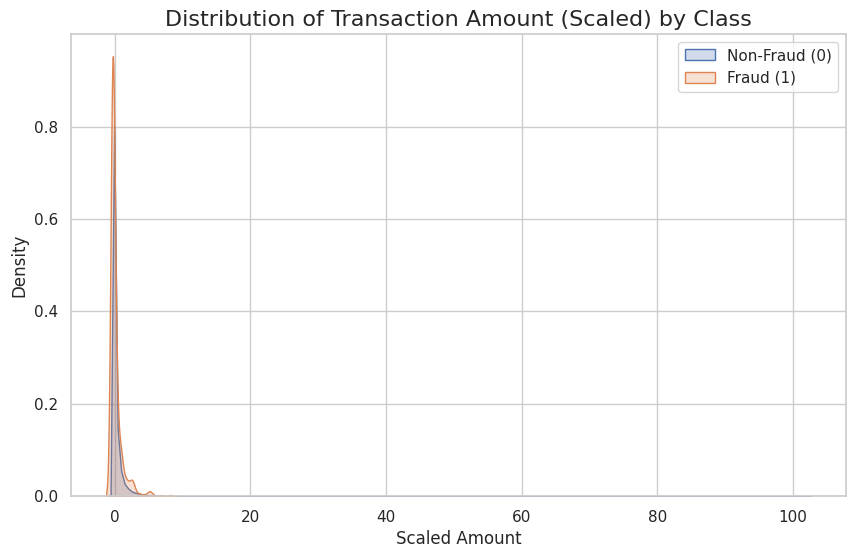

/home/spark-8db015b2-f7c7-476c-b5db-f5/.ipykernel/2642/command-7057909604006584-3694859064:24: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df['Class'] == 0, 'Time_Scaled'], label='Non-Fraud (0)', shade=True)
/home/spark-8db015b2-f7c7-476c-b5db-f5/.ipykernel/2642/command-7057909604006584-3694859064:25: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df['Class'] == 1, 'Time_Scaled'], label='Fraud (1)', shade=True)


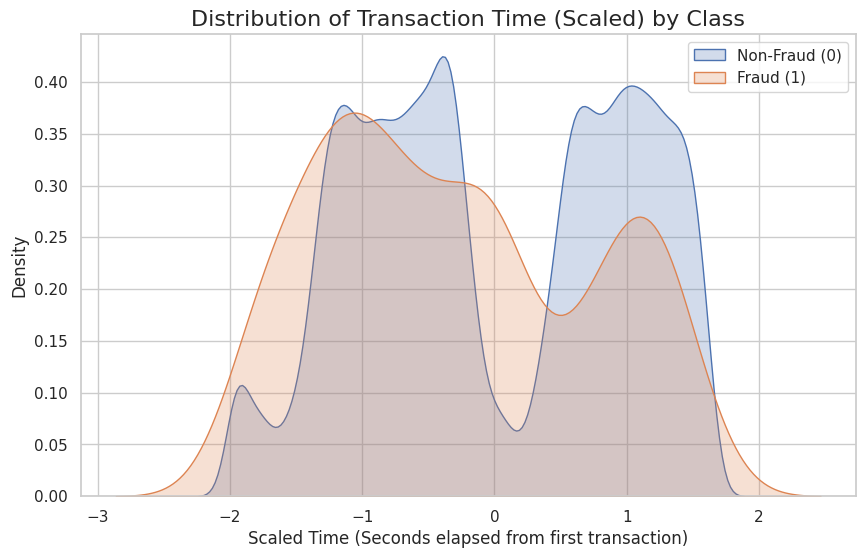

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style for the plots
sns.set_theme(style="whitegrid")

# --- Distribution of Scaled Amount ---
plt.figure(figsize=(10, 6))
# Create a density plot for 'Amount_Scaled', separated by 'Class'
sns.kdeplot(df.loc[df['Class'] == 0, 'Amount_Scaled'], label='Non-Fraud (0)', shade=True)
sns.kdeplot(df.loc[df['Class'] == 1, 'Amount_Scaled'], label='Fraud (1)', shade=True)
plt.title('Distribution of Transaction Amount (Scaled) by Class', fontsize=16)
plt.xlabel('Scaled Amount', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()
# 
# The first graph shows the distribution of transaction amounts (scaled) for both fraud and non-fraud classes.
# It helps visualize if fraudulent transactions tend to have different amounts compared to non-fraudulent ones.

# --- Distribution of Scaled Time ---
plt.figure(figsize=(10, 6))
# Create a density plot for 'Time_Scaled', separated by 'Class'
sns.kdeplot(df.loc[df['Class'] == 0, 'Time_Scaled'], label='Non-Fraud (0)', shade=True)
sns.kdeplot(df.loc[df['Class'] == 1, 'Time_Scaled'], label='Fraud (1)', shade=True)
plt.title('Distribution of Transaction Time (Scaled) by Class', fontsize=16)
plt.xlabel('Scaled Time (Seconds elapsed from first transaction)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()
# 
# The second graph shows the distribution of transaction times (scaled) for both classes.
# This can reveal if fraudulent transactions are more likely to occur at certain times compared to non-fraudulent ones.

Analyzing Class Imbalance

In [0]:
%sql
SELECT
    Amount,
    COUNT(Amount) AS TransactionCount,
    (COUNT(Amount) * 100.0 / SUM(COUNT(Amount)) OVER ()) AS Percentage
FROM
    workspace.default.credit_card_transactions
GROUP BY
    Amount;

Amount,TransactionCount,Percentage
10.0,1,20.00000000000000
20.0,1,20.00000000000000
1000.0,1,20.00000000000000
15.0,1,20.00000000000000
25.0,1,20.00000000000000


Feature Aggregation by Class

This query replicates the statistical comparisons (like means) between the fraud and non-fraud classes.

In [0]:
%sql
SELECT
    TransactionID,
    Amount
FROM
    workspace.default.credit_card_transactions
ORDER BY
    TransactionID;

TransactionID,Amount
1,10.0
2,20.0
3,1000.0
4,15.0
5,25.0


Databricks visualization. Run in Databricks to view.

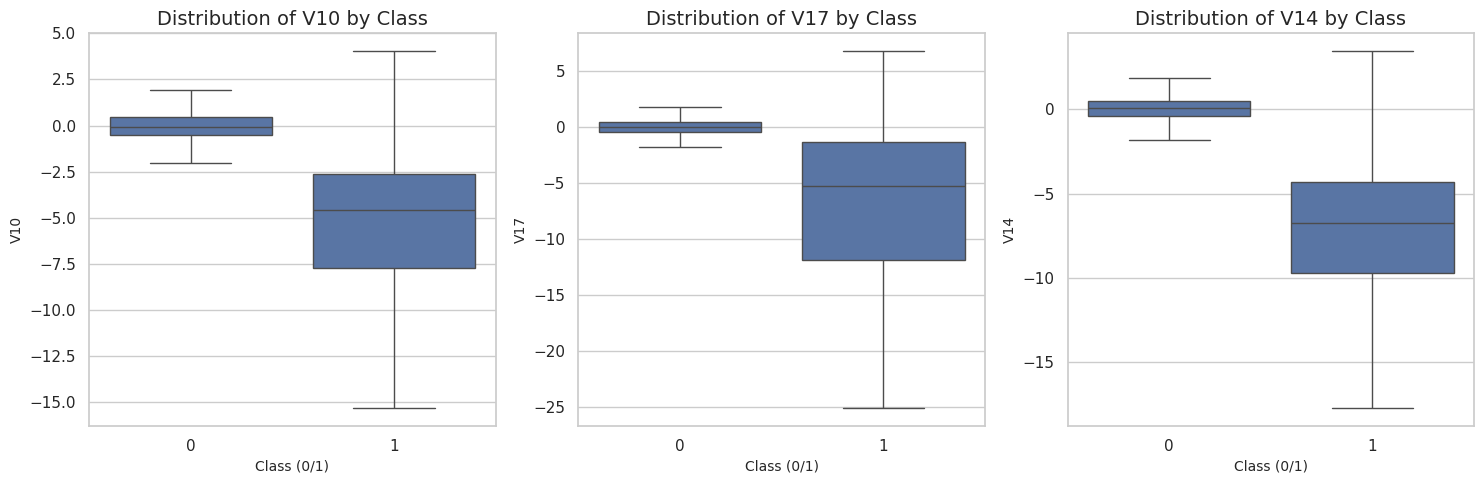

In [0]:
# Select a few 'V' features that are known to show separation for visualization
v_features_to_plot = ['V10', 'V17', 'V14'] # Features highly related to fraud in this dataset

plt.figure(figsize=(15, 5))
for i, feature in enumerate(v_features_to_plot):
    plt.subplot(1, 3, i + 1) # 1 row, 3 columns, i+1 plot
    sns.boxplot(x='Class', y=feature, data=df, showfliers=False) # Hide extreme outliers to see the main distribution
    plt.title(f'Distribution of {feature} by Class', fontsize=14)
    plt.xlabel('Class (0/1)', fontsize=10)
    plt.ylabel(feature, fontsize=10)

plt.tight_layout()
plt.show()

The boxplots in Cell 3 show that the distributions of V10, V17, and V14 are noticeably different between fraudulent and non-fraudulent transactions. For each feature, the median and spread for fraud cases (Class=1) are distinct from non-fraud cases (Class=0), indicating these features help separate fraud from normal transactions. This suggests V10, V17, and V14 are informative for fraud detection.